#### Business Questions

> Which products are frequently out of stock?

> Which suppliers have the highest delivery delays?

> Which products generate the highest profit?

> How can inventory be optimized?

> What is the impact of delivery delays on sales?

#### `Step 0 :- Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Step 1 :- Load Dataset`

In [2]:
# Load dataset
data_frame = pd.read_excel('Project_3_Supply_Chain_Inventory.xlsx')

# Display dataset information
print(f'Shape: {data_frame.shape}')

print(f'\nColumns:\n{data_frame.columns}')

# Display first 5 rows
data_frame.head()

Shape: (15000, 13)

Columns:
Index(['Product_ID', 'Product_Name', 'Category', 'Supplier_Name', 'Order_Date',
       'Delivery_Date', 'Stock_Quantity', 'Reorder_Level', 'Units_Sold',
       'Purchase_Cost', 'Selling_Price', 'Warehouse_Location',
       'Shipping_Time_Days'],
      dtype='str')


,Product_ID,Product_Name,Category,Supplier_Name,Order_Date,Delivery_Date,Stock_Quantity,Reorder_Level,Units_Sold,Purchase_Cost,Selling_Price,Warehouse_Location,Shipping_Time_Days
0,PROD1000,Tablet,Fashion,Supplier D,2023-08-02,2023-08-07,3,59,241,1800,2081,Chennai,5
1,PROD1001,Tablet,Fashion,Supplier D,2024-04-11,2024-04-13,118,105,70,1950,2169,Hyderabad,2
2,PROD1002,Mixer,Sports,Supplier A,2024-08-16,2024-08-20,57,108,107,828,1322,Bangalore,4
3,PROD1003,TV,Sports,Supplier B,2024-11-30,2024-12-02,420,129,271,317,598,Chennai,2
4,PROD1004,Mixer,Fashion,Supplier C,2024-08-03,2024-08-11,401,77,210,645,1061,Mumbai,8


#### `Step 2 :- Data Cleaning`

In [3]:
# Check dataset size
print(f'Before removing duplicates: {data_frame.shape}')

# Remove duplicate records
data_frame = data_frame.drop_duplicates()

# Check dataset size again
print(f'After removing duplicates: {data_frame.shape}')

# Verify duplicate records
print(f'Remaining Duplicates: {data_frame.duplicated().sum()}')

Before removing duplicates: (15000, 13)
After removing duplicates: (15000, 13)
Remaining Duplicates: 0


In [4]:
# Check missing values
print(f'Missing Values:\n{data_frame.isnull().sum()}')

# Numeric columns
numeric_columns = [
    'Stock_Quantity',
    'Reorder_Level',
    'Units_Sold',
    'Purchase_Cost',
    'Selling_Price',
    'Shipping_Time_Days']

# Convert numeric columns
for column in numeric_columns:

    data_frame[column] = pd.to_numeric(
        data_frame[column],
        errors = 'coerce')

# Fill missing numeric values
data_frame[numeric_columns] = (
    data_frame[numeric_columns]
    .fillna(0))

# Categorical columns
categorical_columns = [
    'Product_Name',
    'Category',
    'Supplier_Name',
    'Warehouse_Location']

# Fill missing categorical values
for column in categorical_columns:

    data_frame[column] = data_frame[column].fillna('Unknown')

# Verify missing values
print(f'\nMissing Values After Cleaning:\n{data_frame.isnull().sum()}')

Missing Values:
Product_ID            0
Product_Name          0
Category              0
Supplier_Name         0
Order_Date            0
Delivery_Date         0
Stock_Quantity        0
Reorder_Level         0
Units_Sold            0
Purchase_Cost         0
Selling_Price         0
Warehouse_Location    0
Shipping_Time_Days    0
dtype: int64

Missing Values After Cleaning:
Product_ID            0
Product_Name          0
Category              0
Supplier_Name         0
Order_Date            0
Delivery_Date         0
Stock_Quantity        0
Reorder_Level         0
Units_Sold            0
Purchase_Cost         0
Selling_Price         0
Warehouse_Location    0
Shipping_Time_Days    0
dtype: int64


In [5]:
# Format date columns
date_columns = [
    'Order_Date',
    'Delivery_Date']

for column in date_columns:

    data_frame[column] = pd.to_datetime(
        data_frame[column],
        errors = 'coerce')

print(data_frame[date_columns].dtypes)

Order_Date       datetime64[us]
Delivery_Date    datetime64[us]
dtype: object


In [6]:
# Check negative stock values
negative_stock = (
    data_frame['Stock_Quantity'] < 0 ).sum()

print(f'Negative Stock Records: {negative_stock}')

# Replace negative stock values with 0
data_frame.loc[
    data_frame['Stock_Quantity'] < 0,
    'Stock_Quantity'] = 0

print(
    f'Negative Stock After Cleaning: '
    f'{(data_frame["Stock_Quantity"] < 0).sum()}')

Negative Stock Records: 0
Negative Stock After Cleaning: 0


In [7]:
# Standardize column names
data_frame.columns = (
    data_frame.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_'))

print(f'Columns:\n{data_frame.columns.tolist()}')

Columns:
['Product_ID', 'Product_Name', 'Category', 'Supplier_Name', 'Order_Date', 'Delivery_Date', 'Stock_Quantity', 'Reorder_Level', 'Units_Sold', 'Purchase_Cost', 'Selling_Price', 'Warehouse_Location', 'Shipping_Time_Days']


#### `Step 3 :- Supply Chain Analysis`

In [8]:
# Calculate total units sold
total_units_sold = data_frame['Units_Sold'].sum()

print(f'Total Units Sold: {total_units_sold:,}')

Total Units Sold: 2,222,508


In [9]:
# Calculate total revenue
data_frame['Revenue'] = (
    data_frame['Units_Sold'] *
    data_frame['Selling_Price'])

total_revenue = data_frame['Revenue'].sum()

print(f'Total Revenue: ${total_revenue:,.2f}')

Total Revenue: $3,076,312,144.00


In [10]:
# Calculate profit for each product
data_frame['Profit'] = (
    data_frame['Selling_Price'] -
    data_frame['Purchase_Cost']
) * data_frame['Units_Sold']

total_profit = data_frame['Profit'].sum()

print(f'Total Profit: ${total_profit:,.2f}')

Total Profit: $612,924,204.00


In [11]:
# Calculate average shipping time
average_shipping_time = (
    data_frame['Shipping_Time_Days']
    .mean())

print(
    f'Average Shipping Time: '
    f'{average_shipping_time:.2f} Days')

Average Shipping Time: 5.50 Days


In [12]:
# Calculate total stock available
total_stock = (
    data_frame['Stock_Quantity']
    .sum())

print(f'Total Stock Available: {total_stock:,}')

Total Stock Available: 3,763,769


In [13]:
# Calculate total reorder level
total_reorder = (
    data_frame['Reorder_Level']
    .sum())

print(f'Total Reorder Level: {total_reorder:,}')

Total Reorder Level: 1,497,037


In [14]:
# Compare stock available and units sold
stock_summary = pd.DataFrame({

    'Metric': [
        'Stock Available',
        'Units Sold'
    ],

    'Value': [
        total_stock,
        total_units_sold
    ]})

stock_summary

,Metric,Value
0,Stock Available,3763769
1,Units Sold,2222508


#### `Step 4 :- Inventory & Supplier Analysis`

In [15]:
# Identify inventory status
inventory_status = data_frame.copy()

inventory_status['Inventory_Status'] = np.where(
    inventory_status['Stock_Quantity'] <= inventory_status['Reorder_Level'],
    'Understock',
    'Overstock')

inventory_summary = (
    inventory_status['Inventory_Status']
    .value_counts())

inventory_summary

Inventory_Status
Overstock     11985
Understock     3015
Name: count, dtype: int64

In [16]:
# Find products that need restocking
understock_products = (
    inventory_status[
        inventory_status['Inventory_Status'] == 'Understock'
    ]
    .groupby('Product_Name')['Stock_Quantity']
    .sum()
    .sort_values())

understock_products.head(10)

Product_Name
Mixer     14847
Watch     15320
Shoes     15434
Fan       15646
TV        16414
AC        17111
Phone     17187
Laptop    17610
Camera    17818
Tablet    17843
Name: Stock_Quantity, dtype: int64

In [17]:
# Find fast moving products
fast_moving_products = (
    data_frame.groupby('Product_Name')['Units_Sold']
    .sum()
    .sort_values(ascending = False))

fast_moving_products.head(10)

Product_Name
Camera    240401
Laptop    227840
Mixer     226878
Tablet    222857
Phone     220936
Fan       220851
Watch     219547
AC        218074
TV        217051
Shoes     208073
Name: Units_Sold, dtype: int64

In [18]:
# Find slow moving products
slow_moving_products = (
    data_frame.groupby('Product_Name')['Units_Sold']
    .sum()
    .sort_values())

slow_moving_products.head(10)

Product_Name
Shoes     208073
TV        217051
AC        218074
Watch     219547
Fan       220851
Phone     220936
Tablet    222857
Mixer     226878
Laptop    227840
Camera    240401
Name: Units_Sold, dtype: int64

In [19]:
# Analyze supplier performance
supplier_performance = (
    data_frame.groupby('Supplier_Name')['Units_Sold']
    .sum()
    .sort_values(ascending = False))

supplier_performance

Supplier_Name
Supplier E    452768
Supplier C    448597
Supplier A    447389
Supplier B    442191
Supplier D    431563
Name: Units_Sold, dtype: int64

In [20]:
# Calculate delivery days
data_frame['Delivery_Days'] = (
    data_frame['Delivery_Date'] -
    data_frame['Order_Date']).dt.days

# Average delivery days by supplier
delivery_delay = (
    data_frame.groupby('Supplier_Name')['Delivery_Days']
    .mean()
    .sort_values(ascending = False))

delivery_delay

Supplier_Name
Supplier E    5.545032
Supplier D    5.543818
Supplier B    5.520134
Supplier A    5.481653
Supplier C    5.392505
Name: Delivery_Days, dtype: float64

In [21]:
# Find high profit products
high_profit_products = (
    data_frame.groupby('Product_Name')['Profit']
    .sum()
    .sort_values(ascending = False))

high_profit_products.head(10)

Product_Name
Camera    67289924
Laptop    62301164
Fan       61626332
Watch     61540660
Mixer     61423945
Tablet    60869550
AC        60185648
TV        60042822
Phone     59786820
Shoes     57857339
Name: Profit, dtype: int64

In [22]:
# Find low profit products
low_profit_products = (
    data_frame.groupby('Product_Name')['Profit']
    .sum()
    .sort_values())

low_profit_products.head(10)

Product_Name
Shoes     57857339
Phone     59786820
TV        60042822
AC        60185648
Tablet    60869550
Mixer     61423945
Watch     61540660
Fan       61626332
Laptop    62301164
Camera    67289924
Name: Profit, dtype: int64

In [23]:
# Analyze warehouse inventory
warehouse_inventory = (
    data_frame.groupby('Warehouse_Location')['Stock_Quantity']
    .sum()
    .sort_values(ascending = False))

warehouse_inventory

Warehouse_Location
Bangalore    761135
Mumbai       757200
Hyderabad    755963
Chennai      753070
Delhi        736401
Name: Stock_Quantity, dtype: int64

#### `Step 5 :- Dashboard Creation`

> Create a dashboard to monitor inventory, supplier performance, warehouse inventory, and overall supply chain performance.

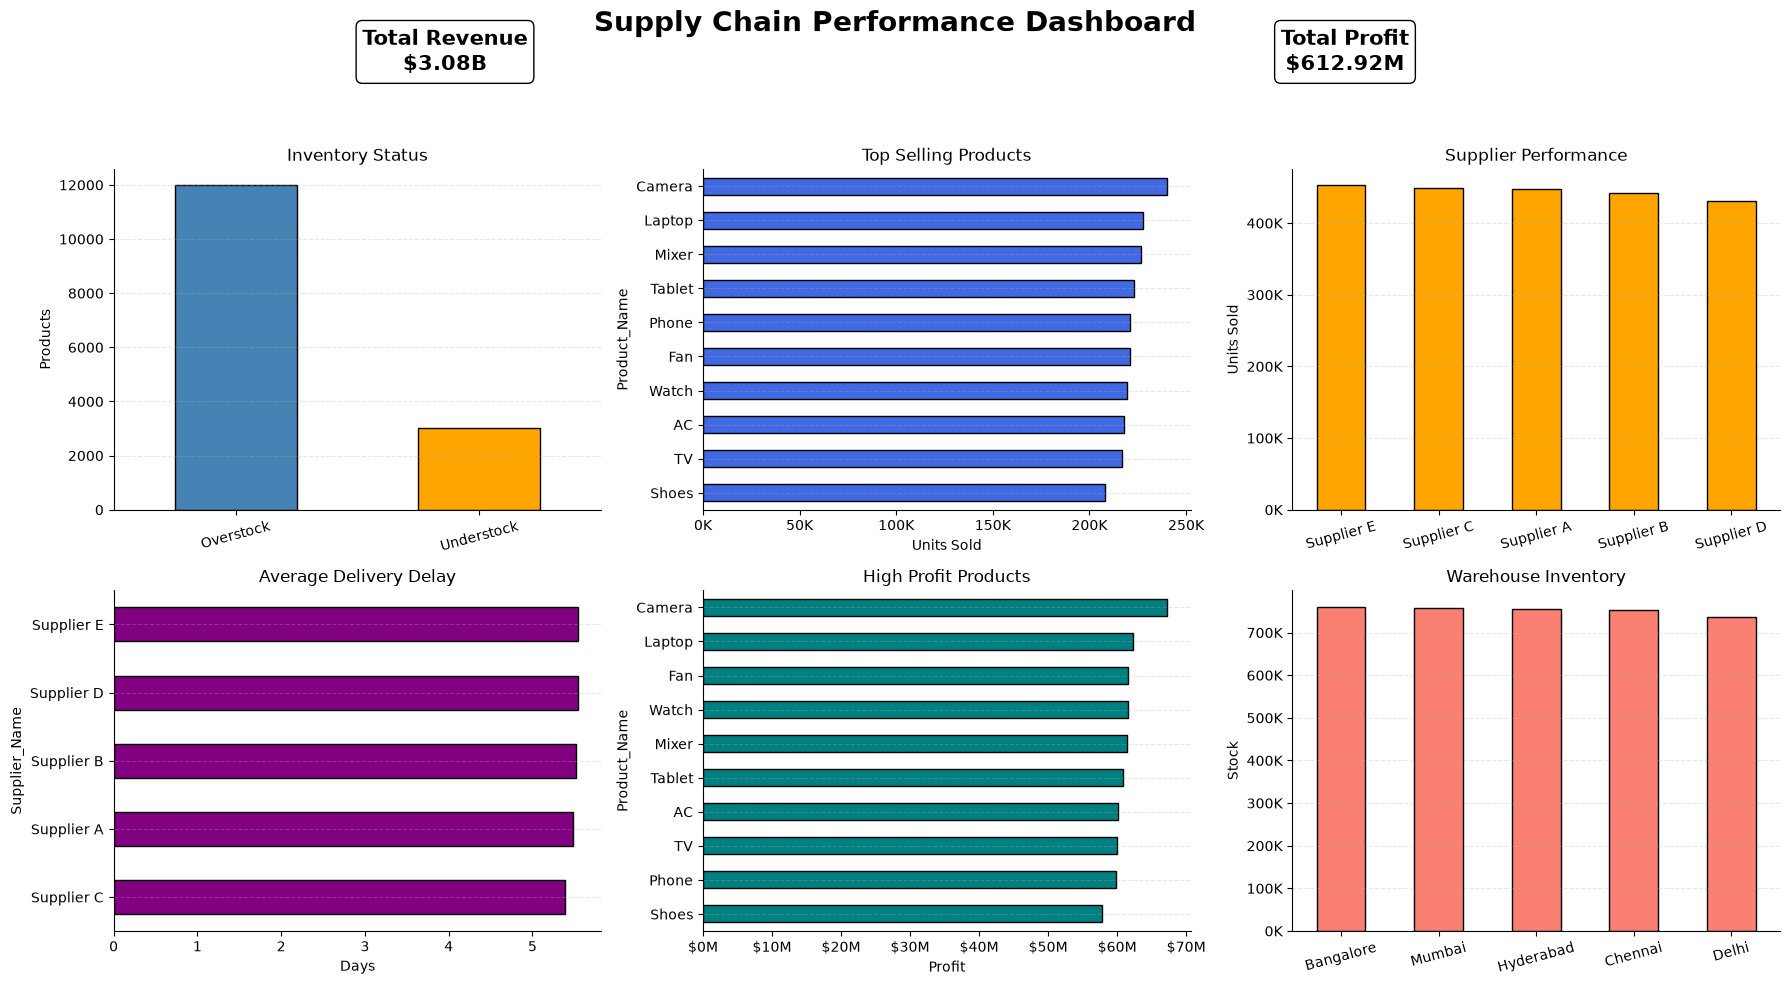

In [31]:
# Create dashboard
dashboard_figure, dashboard_axes = plt.subplots(2, 3, figsize = (18, 10))

# Dashboard title
dashboard_figure.suptitle(
    'Supply Chain Performance Dashboard',
    fontsize = 20,
    fontweight = 'bold')

# KPI Cards
dashboard_figure.text(
    0.25,
    0.92,
    f'Total Revenue\n${total_revenue / 1e9:.2f}B',
    fontsize = 15,
    fontweight = 'bold',
    ha = 'center',
    bbox = dict(
        facecolor = 'white',
        edgecolor = 'black',
        boxstyle = 'round'))

dashboard_figure.text(
    0.75,
    0.92,
    f'Total Profit\n${total_profit / 1e6:.2f}M',
    fontsize = 15,
    fontweight = 'bold',
    ha = 'center',
    bbox = dict(
        facecolor = 'white',
        edgecolor = 'black',
        boxstyle = 'round'))

# Number formatter
thousands_formatter = plt.FuncFormatter(
    lambda x, _: f'{x / 1000:.0f}K')

millions_formatter = plt.FuncFormatter(
    lambda x, _: f'${x / 1e6:.0f}M')

# Inventory Status
inventory_summary.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 0],
    color = ['steelblue', 'orange'],
    edgecolor = 'black')

dashboard_axes[0, 0].set_title('Inventory Status')
dashboard_axes[0, 0].set_xlabel('')
dashboard_axes[0, 0].set_ylabel('Products')
dashboard_axes[0, 0].tick_params(axis = 'x', rotation = 15)

# Top Selling Products
fast_moving_products.head(10).sort_values().plot(
    kind = 'barh',
    ax = dashboard_axes[0, 1],
    color = 'royalblue',
    edgecolor = 'black')

dashboard_axes[0, 1].set_title('Top Selling Products')
dashboard_axes[0, 1].set_xlabel('Units Sold')
dashboard_axes[0, 1].xaxis.set_major_formatter(thousands_formatter)

# Supplier Performance
supplier_performance.plot(
    kind = 'bar',
    ax = dashboard_axes[0, 2],
    color = 'orange',
    edgecolor = 'black')

dashboard_axes[0, 2].set_title('Supplier Performance')
dashboard_axes[0, 2].set_xlabel('')
dashboard_axes[0, 2].set_ylabel('Units Sold')
dashboard_axes[0, 2].tick_params(axis = 'x', rotation = 15)
dashboard_axes[0, 2].yaxis.set_major_formatter(thousands_formatter)

# Delivery Delay
delivery_delay.sort_values().plot(
    kind = 'barh',
    ax = dashboard_axes[1, 0],
    color = 'purple',
    edgecolor = 'black')

dashboard_axes[1, 0].set_title('Average Delivery Delay')
dashboard_axes[1, 0].set_xlabel('Days')

# High Profit Products
high_profit_products.head(10).sort_values().plot(
    kind = 'barh',
    ax = dashboard_axes[1, 1],
    color = 'teal',
    edgecolor = 'black')

dashboard_axes[1, 1].set_title('High Profit Products')
dashboard_axes[1, 1].set_xlabel('Profit')
dashboard_axes[1, 1].xaxis.set_major_formatter(millions_formatter)

# Warehouse Inventory
warehouse_inventory.plot(
    kind = 'bar',
    ax = dashboard_axes[1, 2],
    color = 'salmon',
    edgecolor = 'black')

dashboard_axes[1, 2].set_title('Warehouse Inventory')
dashboard_axes[1, 2].set_xlabel('')
dashboard_axes[1, 2].set_ylabel('Stock')
dashboard_axes[1, 2].tick_params(axis = 'x', rotation = 15)
dashboard_axes[1, 2].yaxis.set_major_formatter(thousands_formatter)

# Improve readability
for row in dashboard_axes:
    for chart in row:

        chart.grid(axis = 'y', linestyle = '--', alpha = 0.3)

        chart.spines['top'].set_visible(False)

        chart.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout(rect = [0, 0, 1, 0.90])

# Save dashboard
plt.savefig(
    '3_Project.png',
    dpi = 300,
    bbox_inches = 'tight')

# Display dashboard
plt.show()

#### Information

> Dataset: Supply Chain & Inventory

> Rows: 15,000

> Original Columns: 13

> Final Columns: 15

> Added Features: Revenue, Profit, Delivery_Days

> No duplicate records were found.

> Missing values were handled.

> Negative stock values were validated.

#### Data Insights

> Total Revenue reached $3.08B.

> Total Profit reached $612.92M.

> Total Units Sold reached 2.22M.

> Average Shipping Time was 5.50 days.

> Overstock products were significantly higher than understock products.

> Supplier E recorded the highest units sold (452.8K).

> Camera generated the highest profit.

#### Business Insights

> Most products are currently overstocked, indicating sufficient inventory availability.

> Camera generated the highest total profit among all products.

> Supplier E delivered the highest sales volume.

> Average delivery time remained consistent across all suppliers at approximately 5.5 days.

> Bangalore warehouse stored the highest inventory.

#### Risks

> High inventory levels may increase storage costs.

> Some products require immediate restocking.

> Delivery delays may affect customer satisfaction.

#### Opportunities

> Reduce excess inventory.

> Improve supplier delivery performance.

> Increase stock for fast-moving products.

#### Recommendations

> Maintain inventory based on reorder levels.

> Increase stock for high-demand products.

> Monitor supplier delivery performance regularly.

> Reduce excess inventory to lower storage costs.

#### Expected Business Impact

> Better inventory utilization.

> Lower inventory costs.

> Faster product availability.

> Improved supply chain efficiency.

#### Future Prediction

> Fast-moving products are expected to remain the major revenue contributors, while better inventory planning can further improve profitability.